# Exercise 2 — ML Key Challenges


In this exercise, you will train several models and observe three cases:

1. Underfitting — model too simple
2. Good fit — model captures the pattern
3. Overfitting — model memorizes the noise

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


Create synthetic nonlinear data

In [2]:
np.random.seed(42)

X = np.linspace(0, 10, 80).reshape(-1, 1)

y_true = np.sin(X).ravel()

y = y_true + np.random.normal(0, 0.25, size=y_true.shape)


Train / test split

In [3]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# For smooth plotting
x_plot = np.linspace(0, 10, 300).reshape(-1, 1)

In [4]:
models = [
    {"degree": 1, "name": "Model A"},
    {"degree": 4, "name": "Model B"},
    {"degree": 15, "name": "Model C"},
]

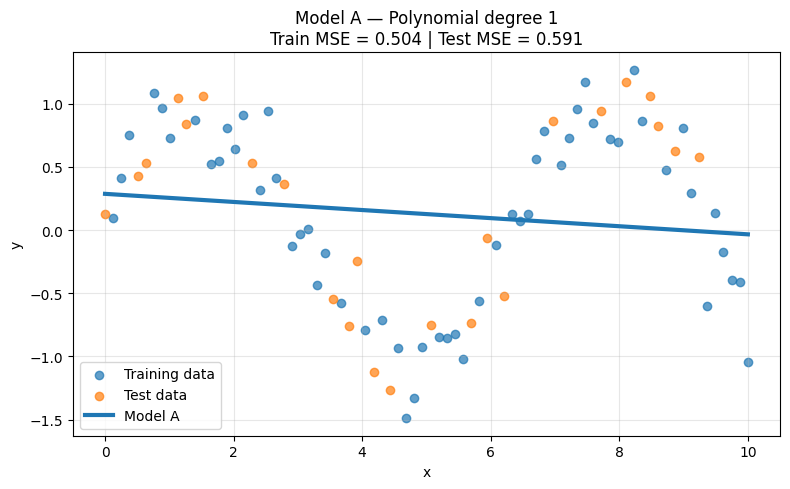

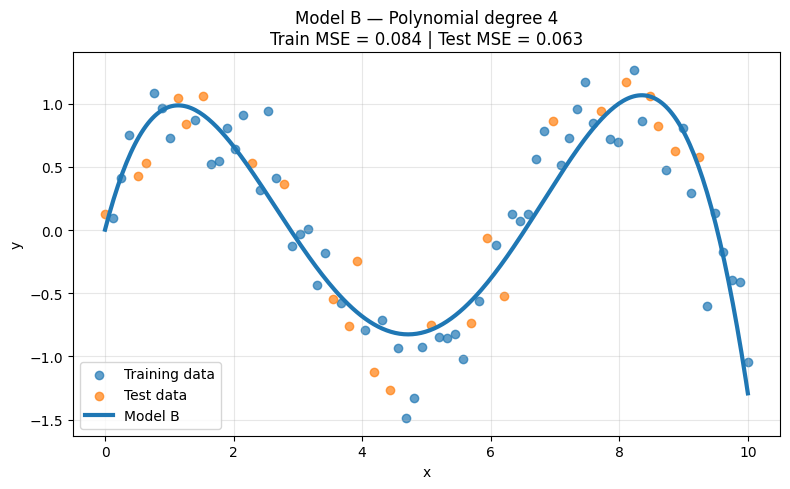

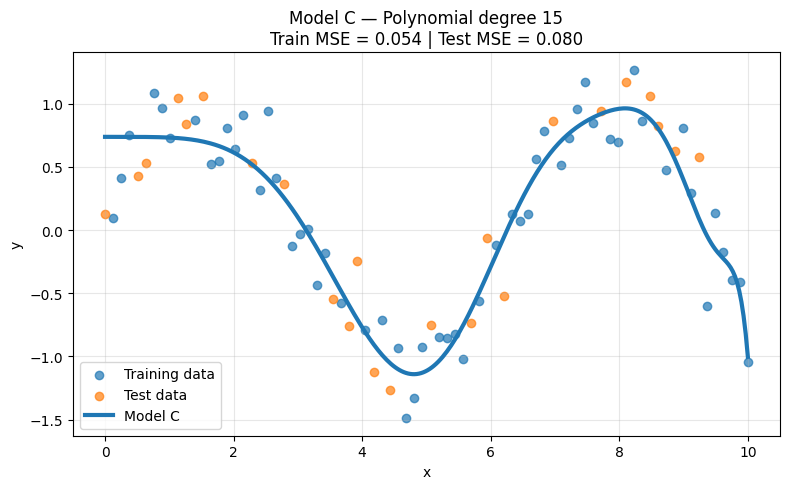

In [5]:
for item in models:
    degree = item["degree"]

    model = make_pipeline(
        PolynomialFeatures(degree),
        LinearRegression()
    )

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_plot = model.predict(x_plot)

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    plt.figure(figsize=(8, 5))

    plt.scatter(X_train, y_train, alpha=0.7, label="Training data")
    plt.scatter(X_test, y_test, alpha=0.7, label="Test data")
    plt.plot(x_plot, y_plot, linewidth=3, label=item["name"])

    plt.title(
        f"{item['name']} — Polynomial degree {degree}\n"
        f"Train MSE = {train_mse:.3f} | Test MSE = {test_mse:.3f}"
    )

    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Questions

1. Which model is underfitting?
2. Which model is overfitting?
3. Which model generalizes best?
4. How do you know from the plot?
5. How do you know from the train/test MSE?

1. Model 1 is underfitting
2. Model 3 is overfitting
3. Model 2 generalizes best

4. - From the first plot, we can clearly see that the error (the distance) between the training value points and the predicted value line is very large. The model did not predict well on the training data and so it did not predict well on the test data. If we plot also the residual lines then this proves that the model is underfitting.
   - From the second plot, the curve is much more smooth and closer to the training data points. Then looking at the test data points, they are also pretty close to the curve. Some noises are further to this curve, so this model generalizes well.
   - From the third plot, if we look at some training data points at the right side, these are noises. However this model actually predict too accurate for these noises, which means overfitting. This leads to more error when the test data comes in (the test data points on the left side are now further to the curve comparing to the second curve)
5. - Model A: Highest train MSE of all - highest test MSE of all -> underfitting
   - Model B: Low train MSE - lowest test MSE of all -> generalizes well
   - Model C: Lowest train MSE - higher test MSE than model B -> overfitting